# Load leaves

In [7]:
import numpy as np

path = "/Volumes/Lab/Users/alexth/axolotl/201808079/data006_unit_859_leaves.npz"

data = np.load(path, allow_pickle=False)

print("Keys:", data.files)

leaf_spike_times = {k: data[k] for k in data.files}
data.close()   # optional but good practice


Keys: ['leaf_00', 'leaf_01', 'leaf_02', 'leaf_03', 'leaf_04', 'leaf_05', 'leaf_06', 'leaf_07', 'leaf_08', 'leaf_09', 'leaf_10', 'leaf_11', 'leaf_12', 'leaf_13', 'leaf_14', 'leaf_15', 'leaf_16', 'leaf_17', 'leaf_18', 'leaf_19', 'leaf_20', 'leaf_21', 'leaf_22', 'leaf_23', 'leaf_24', 'leaf_25', 'leaf_26', 'leaf_27', 'leaf_28', 'leaf_29', 'leaf_30', 'leaf_31', 'leaf_32', 'leaf_33', 'leaf_34', 'leaf_35', 'leaf_36', 'leaf_37', 'leaf_38', 'leaf_39', 'leaf_40', 'leaf_41']


In [9]:
import h5py

path = '/Volumes/Lab/Users/alexth/axolotl/201808079/data006_triggers.h5'
with h5py.File(path, 'r') as h5:
    triggers_sec = h5['/triggers'][...]         # shape (4303, 1) or (4303,)
triggers_sec = np.ravel(triggers_sec).astype(np.float64)  # 1D float64
len(triggers_sec)  # should be 4303


4303

In [13]:

spk_leaf = leaf_spike_times[f'leaf_13']
print(len(spk_leaf))

23058


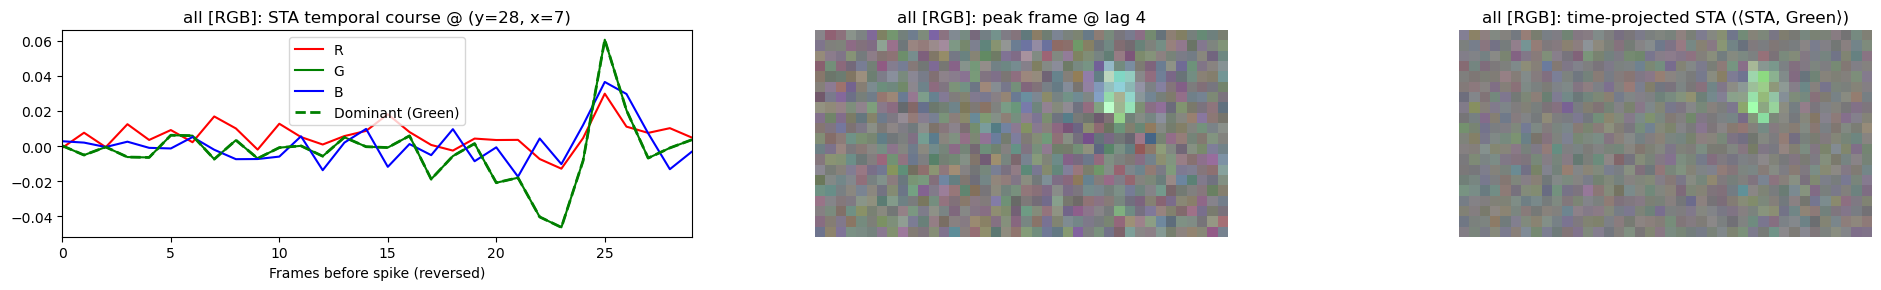

In [14]:

from axolotl_utils_ram import compute_and_plot_sta

leaf_id = 13

spk_leaf = leaf_spike_times[f'leaf_{leaf_id}']

sta0, red_tc0, green_tc0, blue_tc0 = compute_and_plot_sta(spk_leaf, triggers_sec, STA_DEPTH=30, STA_OFFSET=2, STA_CHUNK=1000, STA_REFRESH=2, SEED=33333, W=20, H=40, label="all", peak_frame=None, mode="rgb")


In [15]:
import os, json
import numpy as np
import scipy.io as sio

JSON_PATH = "/Volumes/Lab/Users/alexth/axolotl/201808079/leaves_to_extract.json"
OUT_DIR   = "/Volumes/Lab/Users/alexth/axolotl/201808079/matlab_files"
OUT_FILE  = os.path.join(OUT_DIR, "extracted_spike_times.mat")

os.makedirs(OUT_DIR, exist_ok=True)

with open(JSON_PATH, "r") as f:
    entries = json.load(f)

base_dir = os.path.dirname(JSON_PATH)

def load_leaf_arrays_npz(path):
    """
    Return a dict mapping integer leaf index -> 1D np.int64 spike array
    from an .npz saved as {'leaf_00': arr, 'leaf_01': arr, ...}.
    """
    z = np.load(path, allow_pickle=False)
    idx_to_arr = {}
    for key in z.files:
        # accept 'leaf_00', 'leaf_1', etc.
        if key.startswith("leaf_"):
            suffix = key[len("leaf_"):]
            try:
                k = int(suffix)  # works for '0', '00', '01', '10'
            except ValueError:
                # maybe 'leaf_00' style; strip leading zeros still fine
                continue
            arr = np.asarray(z[key], dtype=np.int64).ravel()
            idx_to_arr[k] = arr
    if not idx_to_arr:
        raise KeyError(f"No 'leaf_*' arrays found in {path}")
    return idx_to_arr

filenames = []         # MATLAB 1xN cell of char
leaf_index_lists = []  # MATLAB 1xN cell of column vectors (int)
spike_cells = []       # MATLAB 1xN cell of column vectors (combined spikes)

for e in entries:
    fname = e["filename"]
    idxs  = e.get("leaf_indices", [])
    if not idxs:
        continue

    if not os.path.isabs(fname):
        fname = os.path.join(base_dir, fname)

    if not os.path.exists(fname):
        raise FileNotFoundError(f"{fname} not found")

    # read per-leaf arrays from NPZ
    idx_to_arr = load_leaf_arrays_npz(fname)

    # collect spikes from requested leaves; tolerate missing leaves with a clear error
    spikes_all = []
    missing = []
    for idx in idxs:
        if idx in idx_to_arr:
            spikes_all.append(idx_to_arr[idx])
        else:
            # try zero-padded fallback (e.g., JSON has 3 but keys are 'leaf_03')
            key_padded = f"leaf_{idx:02d}"
            key_plain  = f"leaf_{idx}"
            has = key_padded in idx_to_arr or idx in idx_to_arr
            if not has:
                missing.append(idx)

    if missing:
        raise KeyError(f"{fname}: missing leaves {missing}; available={sorted(idx_to_arr.keys())[:10]}...")

    # combine spikes
    combined = np.concatenate(spikes_all) if spikes_all else np.empty(0, dtype=np.int64)

    # optional: deduplicate if leaves can overlap
    # combined = np.unique(combined)

    combined.sort()
    combined = combined.reshape(-1, 1)  # MATLAB column

    filenames.append(fname)
    leaf_index_lists.append(np.asarray(idxs, dtype=np.int64).reshape(-1, 1))
    spike_cells.append(combined)

# pack for MATLAB as cell arrays
filenames_cell     = np.array(filenames, dtype=object).reshape(1, -1)
leaf_indices_cell  = np.empty(len(leaf_index_lists), dtype=object)
spike_times_cell   = np.empty(len(spike_cells), dtype=object)

for i, (li, st) in enumerate(zip(leaf_index_lists, spike_cells)):
    leaf_indices_cell[i] = li
    spike_times_cell[i]  = st

payload = {
    "filenames":    filenames_cell,
    "leaf_indices": leaf_indices_cell.reshape(1, -1),
    "spike_times":  spike_times_cell.reshape(1, -1),
}

sio.savemat(OUT_FILE, payload, do_compression=True)
print(f"Saved: {OUT_FILE}")


Saved: /Volumes/Lab/Users/alexth/axolotl/201808079/matlab_files/extracted_spike_times.mat
